# Import the libraries and configure a spark session

In [1]:
from pyspark.sql import SparkSession
import os
import pyspark.sql.functions as sf
from pyspark.sql import Window

In [2]:
# Get the access and secret keys to connect to s3
access_key = os.getenv("S3_ACCESS_KEY")
secret_key = os.getenv("S3_SECRET_KEY") 

# Create a spark session including modules to connect to s3
# Added the third line in which I can set manually the memory usage for each worker
spark = SparkSession.builder \
    .master("spark://master:7077")\
    .appName("Anomaly Detection")\
    .config("spark.executor.memory", "1g")\
    .config('spark.jars.packages', 'org.apache.hadoop:hadoop-aws:3.4.1,org.apache.hadoop:hadoop-common:3.4.1')\
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")\
    .config("spark.sql.execution.arrow.pyspark.fallback.enabled", "false")\
    .config('spark.hadoop.fs.s3a.aws.credentials.proviAnvoder', 'org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider')\
    .config('spark.hadoop.fs.s3a.access.key', access_key)\
    .config('spark.hadoop.fs.s3a.secret.key', secret_key)\
    .config('spark.hadoop.fs.s3a.endpoint', 'https://cloud-areapd.pd.infn.it:5210')\
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.metadatastore.impl", "org.apache.hadoop.fs.s3a.s3guard.NullMetadataStore") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled","false") \
    .config("com.amazonaws.sdk.disableCertChecking","true") \
    .getOrCreate()

:: loading settings :: url = jar:file:/usr/local/spark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/pandreac/.ivy2.5.2/cache
The jars for the packages stored in: /home/pandreac/.ivy2.5.2/jars
org.apache.hadoop#hadoop-aws added as a dependency
org.apache.hadoop#hadoop-common added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-ffd92fa9-0180-4724-b399-c58eb9a82d76;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.4.1 in central
	found software.amazon.awssdk#bundle;2.24.6 in central
	found org.wildfly.openssl#wildfly-openssl;1.1.3.Final in central
	found org.apache.hadoop#hadoop-common;3.4.1 in central
	found org.apache.hadoop.thirdparty#hadoop-shaded-protobuf_3_25;1.3.0 in central
	found org.apache.hadoop#hadoop-annotations;3.4.1 in central
	found org.apache.hadoop.thirdparty#hadoop-shaded-guava;1.3.0 in central
	found com.google.guava#guava;27.0-jre in central
	found com.google.guava#failure

# Task 1: conversion of alarms

First of all, we will convert the "A5" and "A9" variables from their integer representation to their bit string one. This will help identifying the required alarms. \
First, we have to read the data file from the CloudVeneto "bucket", converted into the *Parquet* format by  `df_spark.write.mode("overwrite").parquet("s3a://MAPDB-Group5/data_parquet")`

In [3]:
# Read data from the CloudVeneto "bucket" through s3
df_spark = spark.read.parquet("s3a://MAPDB-Group5/data_parquet")
df_spark.show(10)

+-------------+------+------+-----+
|         when|  hwid|metric|value|
+-------------+------+------+-----+
|1604265597702|SW-115|   S80|    0|
|1604265597702|SW-115|   S73|    0|
|1604265597702|SW-115|   S72|  100|
|1604265597702|SW-115|   S71|  100|
|1604265597702|SW-115|   P16|  200|
|1604265597702|SW-115|   P15|    0|
|1604265597702|SW-115|   P10|  430|
|1604265597702|SW-115|    P9|  300|
|1604265597702|SW-115|    P8|  150|
|1604265597702|SW-115|    P7|  260|
+-------------+------+------+-----+
only showing top 10 rows


After reading the data, we can convert the `A5` and `A9` metrics to their bitwise representation

In [4]:
# Converting the A5 and A9 metrics to their bit-string representation
# Note: all the other values are converted into strings because Spark
# wants the same type returned by when/otherwise 
df_spark = df_spark.withColumn(
    "BitString",
    sf.when(
        df_spark.metric.isin('A5', 'A9'),
        sf.lpad(sf.bin(df_spark.value), 16, '0')
    ).otherwise(df_spark.value.cast('string'))
)

Now that we have converted the `A5` and `A9` variables to their bit-string representation, we can identify the requested alarms by checking if 1+ bit(s) in position 6, 7 and 8 (staring from the LSB), are 1 in either or both of them, which means that engines are overheating.

In [5]:
# Starting from the LSB, positions 6, 7 and 8 correspond to position 9, 10 and 11
# because the substring function operates from left to right (so from the MSB)
df_spark = df_spark.withColumn(
    "is_overheated",
    sf.when(
        df_spark.metric.isin('A5', 'A9') & 
        (sf.substring(df_spark.BitString, 9, 3) != '000'),
        True
    ).otherwise(False)
)

After identifying all the requested alarms and flagging them with `is_overheated`, we can resample all the metrics to the same sampling frequency, in order to correctly conduct the analysis. \
We chose the sampling frequence to be **1 minute**

In [6]:
# Overwrite the "when" column, representing a UNIX timestamp, casting that to the native "TimestampType"
# using the native spark function
df_spark = df_spark.withColumn(
    "when",
    sf.timestamp_millis(df_spark.when)
)

# Now let's add a "timestamp_bucket" column, "truncating" everything to the minutes
# to get the same sampling frequency for all data
df_spark = df_spark.withColumn(
    "timestamp_bucket",
    sf.date_trunc("minute", "when")
)

# Use flag "truncate=False" to show the whole timestamp
df_spark.show(10, truncate=False)

+-----------------------+------+------+-----+---------+-------------+-------------------+
|when                   |hwid  |metric|value|BitString|is_overheated|timestamp_bucket   |
+-----------------------+------+------+-----+---------+-------------+-------------------+
|2020-11-01 21:19:57.702|SW-115|S80   |0    |0        |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|S73   |0    |0        |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|S72   |100  |100      |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|S71   |100  |100      |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|P16   |200  |200      |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|P15   |0    |0        |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|P10   |430  |430      |false        |2020-11-01 21:19:00|
|2020-11-01 21:19:57.702|SW-115|P9    |300  |300      |false        |2020-11-01 21:19:00|
|2020-11-0

Now that we have added a `timestamp_bucket`, we need to aggregate all the metrics under the same bucket. 
To do so, we will use the following strategy, which takes into account the nature of the data:

* **Engine status metrics (S117, S118, S169, S170):** these metrics indicate the ON/OFF power state of the engines (engine 1, 2, 3, and 4, respectively). To aggregate them within a single bucket, we use the **maximum value** detected by the system. This guarantees that if an engine was active at any point during that interval, the state is recorded as active (`1`).

* **Discrete states, binary flags, and alarms (e.g., operational modes, valve statuses, and the `is_overheated` flag):** we also aggregate these using the **maximum value** (acting as a logical OR). This ensures that any alarm event or state transition occurring within the bucket is preserved rather than smoothed out.

* **Continuous physical measurements (e.g., temperatures, pressures, powers, and capacities such as S41, S100, S102, S109, S125, E1):** we aggregate these using the **mean value** Now that we have added a `timestamp_bucket`, we need to aggregate all the metrics under the same bucket. 
To do so, we will use the following strategy, which takes into account the nature of the data:

* **Cumulative energy counters (E3, E4, E5, E6):** since these variables represent monotonically increasing cumulative readings, we aggregate them using the **maximum value** to reflect the total accumulated energy at the end of the interval.

In [7]:
# List of all the metrics that should be aggregated using their mean
continuous_metrics = [
    'E1', 'E2',
    'S19', 'S37', 'S39', 'S40', 'S41', 'S42', 'S43', 'S45', 'S46', 'S47', 'S49', 'S50',
    'S69', 'S70', 'S71', 'S72', 'S80', 'S81', 'S83', 'S86', 'S90', 'S94', 'S97',
    'S100', 'S101', 'S102', 'S106', 'S107', 'S108', 'S109', 'S110',
    'S122', 'S124', 'S125', 'S126', 'S128', 'S129',
    'S137', 'S138', 'S140', 'S143', 'S147',
    'S151', 'S154', 'S157', 'S158', 'S159',
    'S163', 'S164', 'S165', 'S166', 'S167',
    'S178', 'S180', 'S181'
]

# Define a window partitioned by timestamp_bucket and device (hwid).
# We omit orderBy and framing to allow Spark to compute the partition-level max
# without maintaining strict ordering, keeping memory overhead minimal.
w_device = Window.partitionBy("timestamp_bucket", "hwid")

# Propagate the "is_overheated" flag across all records belonging to the same device 
# and bucket window. If any alarm (e.g., 'A5' or 'A9') flagged overheating, 
# all rows in that bucket/device will receive True.
df_with_flag = df_spark.withColumn(
    "is_overheated_device",
    sf.max(sf.col("is_overheated")).over(w_device)
)

# It's important to also groupBy "hwid" which indicates the specific device.
# We use the "coalesce" function because if the metric isn't in the "continuous_metrics" list
# the first expression will implicitly return "null".
# Coalesce returns the first not null value, so if the metric isn't in that list, it will
# automatically pass to the second value and return the max
df_aggregated = (
    df_with_flag.groupBy("timestamp_bucket", "hwid", "metric")
      .agg(
          sf.coalesce(
              sf.mean(sf.when(sf.col("metric").isin(continuous_metrics), sf.col("value"))),
              sf.max(sf.col("value"))
          ).alias("aggregated_value"),
          sf.first("is_overheated_device").alias("is_overheated")
      )
)

df_aggregated.show(10)

+-------------------+------+------+----------------+-------------+
|   timestamp_bucket|  hwid|metric|aggregated_value|is_overheated|
+-------------------+------+------+----------------+-------------+
|2020-10-01 00:08:00|SW-088|    P1|             0.0|        false|
|2020-10-01 00:08:00|SW-088|   P10|           450.0|        false|
|2020-10-01 00:08:00|SW-088|   P15|             0.0|        false|
|2020-10-01 00:08:00|SW-088|   P16|           125.0|        false|
|2020-10-01 00:08:00|SW-088|   P17|           400.0|        false|
|2020-10-01 00:08:00|SW-088|   P18|           450.0|        false|
|2020-10-01 00:08:00|SW-088|    P2|             0.0|        false|
|2020-10-01 00:08:00|SW-088|    P5|           300.0|        false|
|2020-10-01 00:08:00|SW-088|    P6|           180.0|        false|
|2020-10-01 00:08:00|SW-088|    P7|           260.0|        false|
+-------------------+------+------+----------------+-------------+
only showing top 10 rows


# Benchmark Analysis — `Data_Benchmarking_Fixed`

The benchmarking suite isolates the four computational steps of this pipeline and measures their
strong-scaling behaviour across **1, 2, 4, and 6 executor cores**, repeating each measurement
five times to obtain stable mean wall-clock times. An additional sweep over
`spark.sql.shuffle.partitions` ∈ {6, 12, 32, 200} characterises the sensitivity of the
shuffle-heavy step to partition count. All figures below are derived directly from
`Data_Benchmarking_Fixed/benchmark_results.json`.

---

## 1. Task characterisation and baseline cost (1 core)

| Task | Spark category | Wall-time @ 1 core | Shuffle I/O |
| --- | --- | --- | --- |
| **Task 1** – `is_overheated` flag (`sf.bin` → `sf.lpad` → `sf.substring`) | Map / Narrow | 0.977 s | 177 B |
| **Task 2** – `timestamp_millis` + `date_trunc` bucket | Map / Narrow | 0.931 s | 177 B |
| **Task 3** – device-level flag propagation (`Window.partitionBy`) | Window / Narrow\* | 0.934 s | 177 B |
| **Task 4** – metric aggregation (`groupBy` + `coalesce(mean, max)`) | Shuffle / Wide | 132.9 s | 708 B |

Tasks 1–3 differ in baseline cost by less than 5 % from one another and all execute in under
1 second. The vanishingly small shuffle I/O (177 B — purely metadata) confirms that Spark
keeps these as **narrow transformations**: no data crosses executor boundaries.
Task 4 is **two orders of magnitude slower** because `groupBy` forces a full hash-shuffle:
every row must be re-partitioned by `(timestamp_bucket, hwid, metric)` before the
`coalesce(mean, max)` aggregation can be computed locally on each partition.

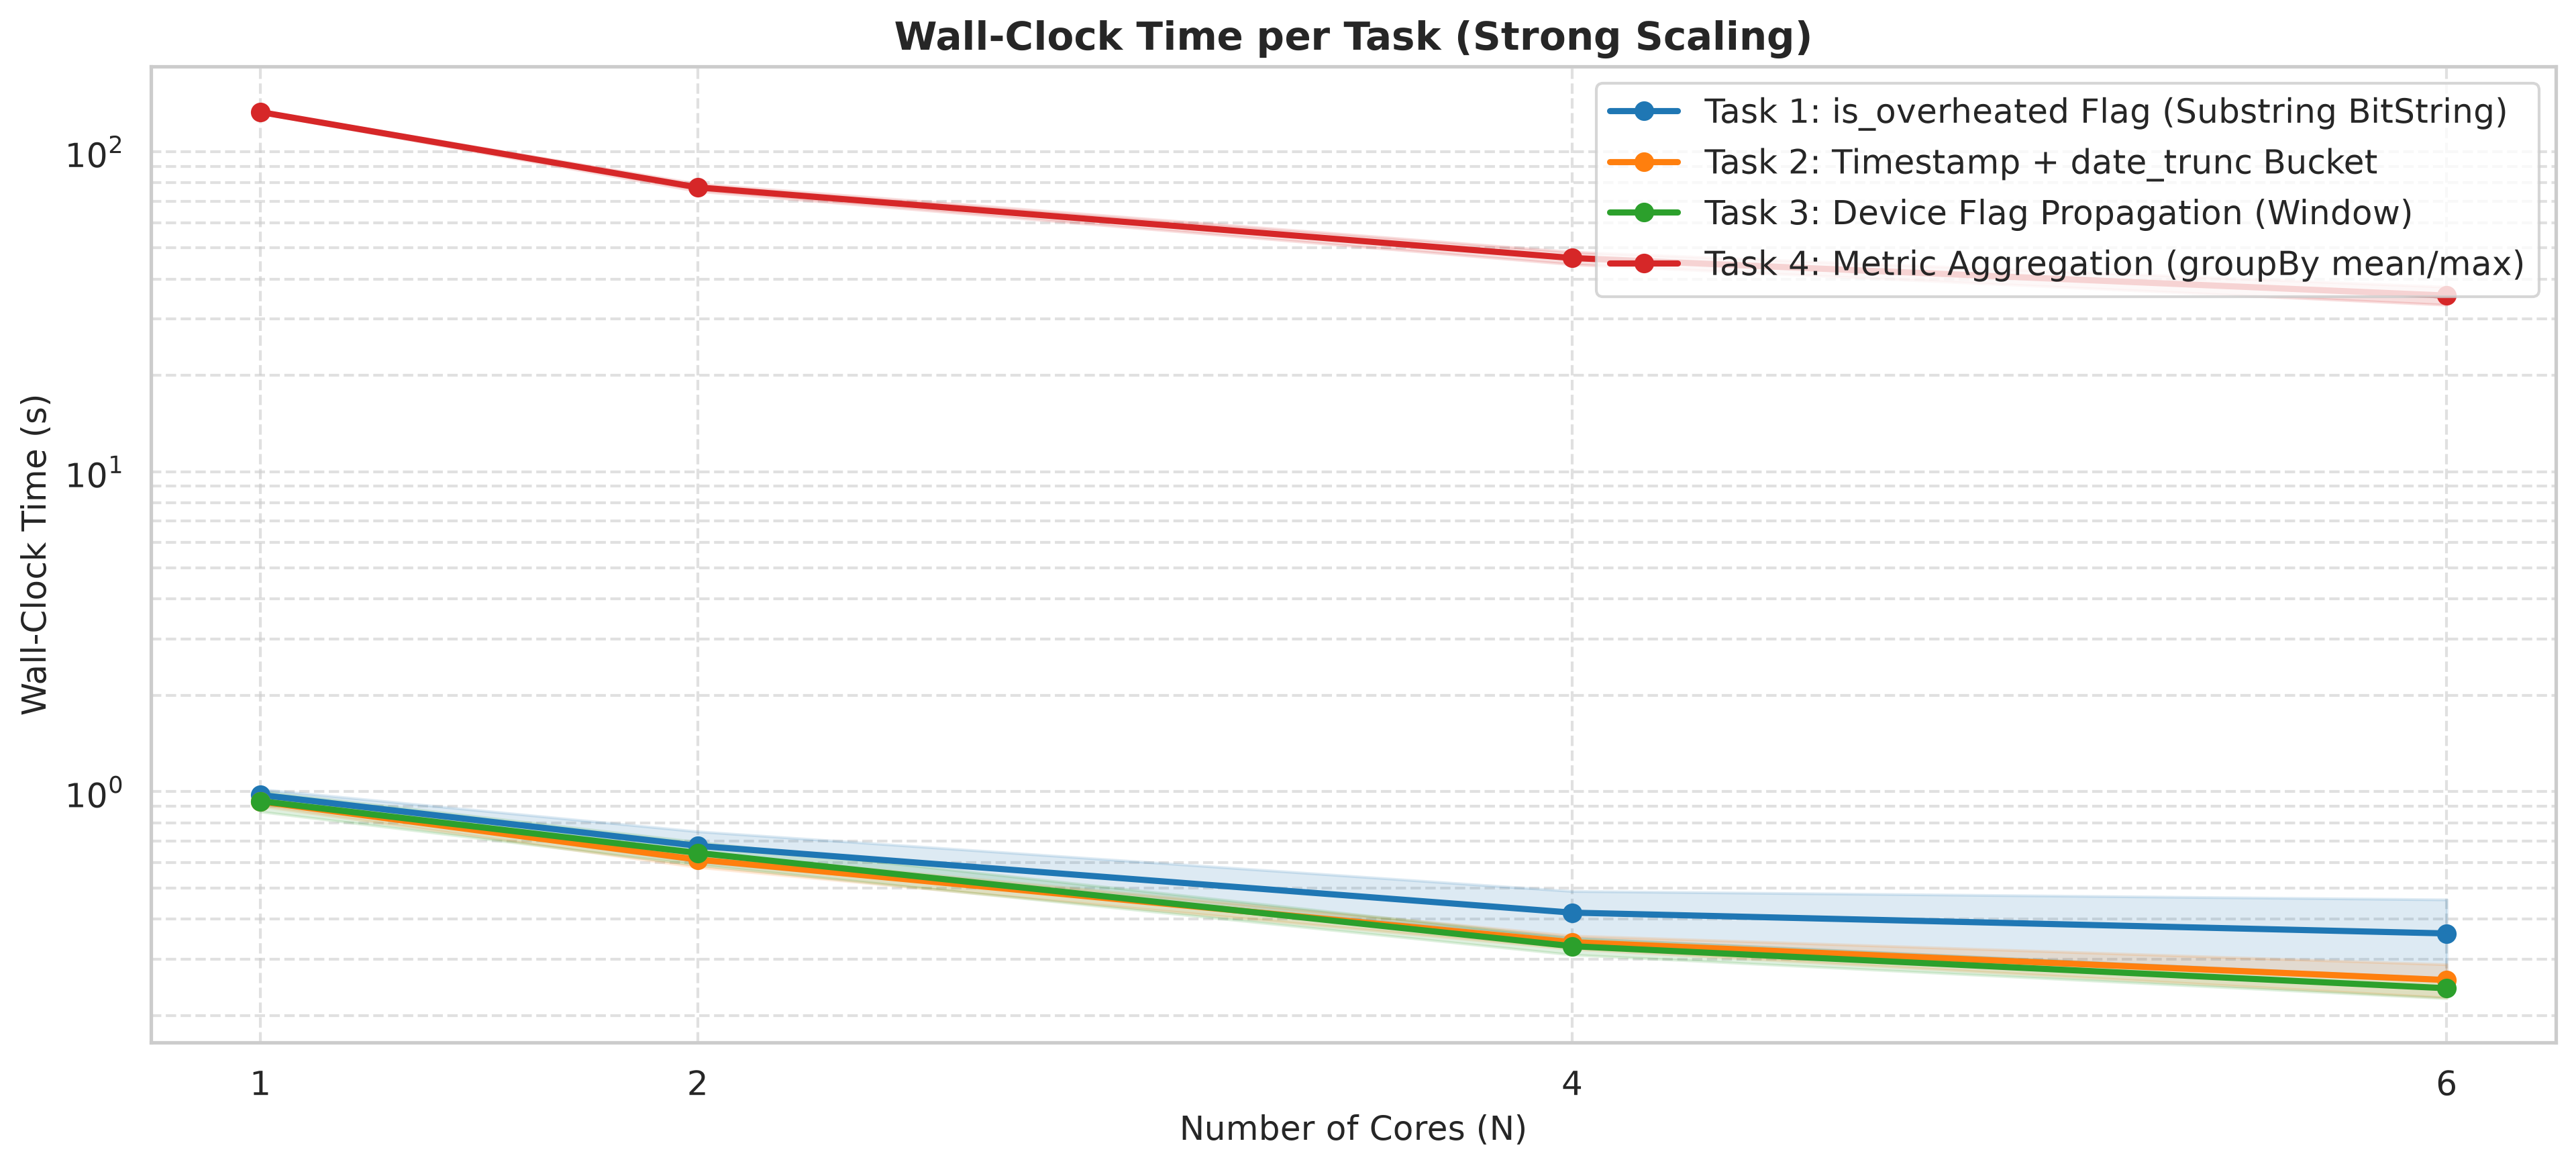

\*Task 3 uses `Window.partitionBy` *without* `orderBy` or an explicit frame, which Spark
optimises into a single-pass partition-local max — effectively a narrow operation at runtime.

---

## 2. Strong-scaling speedup S(N) = T(1) / T(N)

| Task | S(2) | S(4) | S(6) | Ideal S(6) |
| --- | --- | --- | --- | --- |
| Task 1 | 1.44× | 2.33× | 2.71× | 6× |
| Task 2 | 1.52× | 2.75× | 3.61× | 6× |
| Task 3 | 1.45× | 2.84× | **3.84×** | 6× |
| Task 4 | 1.72× | 2.86× | **3.74×** | 6× |

All four tasks scale sub-linearly, as expected under Amdahl's law. The reasons differ by category:

- **Tasks 1–3 (narrow):** At 1 core the total computation takes < 1 s, so a significant
  fraction of that time is **fixed overhead** — Spark driver scheduling, task serialisation,
  and JVM startup. As N grows, the parallel fraction shrinks relative to this fixed cost,
  depressing speedup. Task 1 is the worst case (S(6) = 2.71×) because the
  string-manipulation primitives (`sf.bin`, `sf.lpad`, `sf.substring`) produce
  uneven per-row work depending on the integer value being converted, introducing
  minor **partition-level load imbalance**.

- **Task 4 (wide):** Despite the shuffle cost, Task 4 achieves S(6) = 3.74×. With 6
  executors each stage of the two-phase aggregation (map-side partial aggregate → shuffle
  → reduce-side final aggregate) runs genuinely in parallel. The sub-linear ceiling is
  explained by the **shuffle bottleneck**: total CPU time *increases* with cores
  (from 131 s at 1 core to 151 s at 6 cores) because more executors generate more
  concurrent shuffle write/read traffic, increasing serialisation and network coordination
  overhead proportionally.

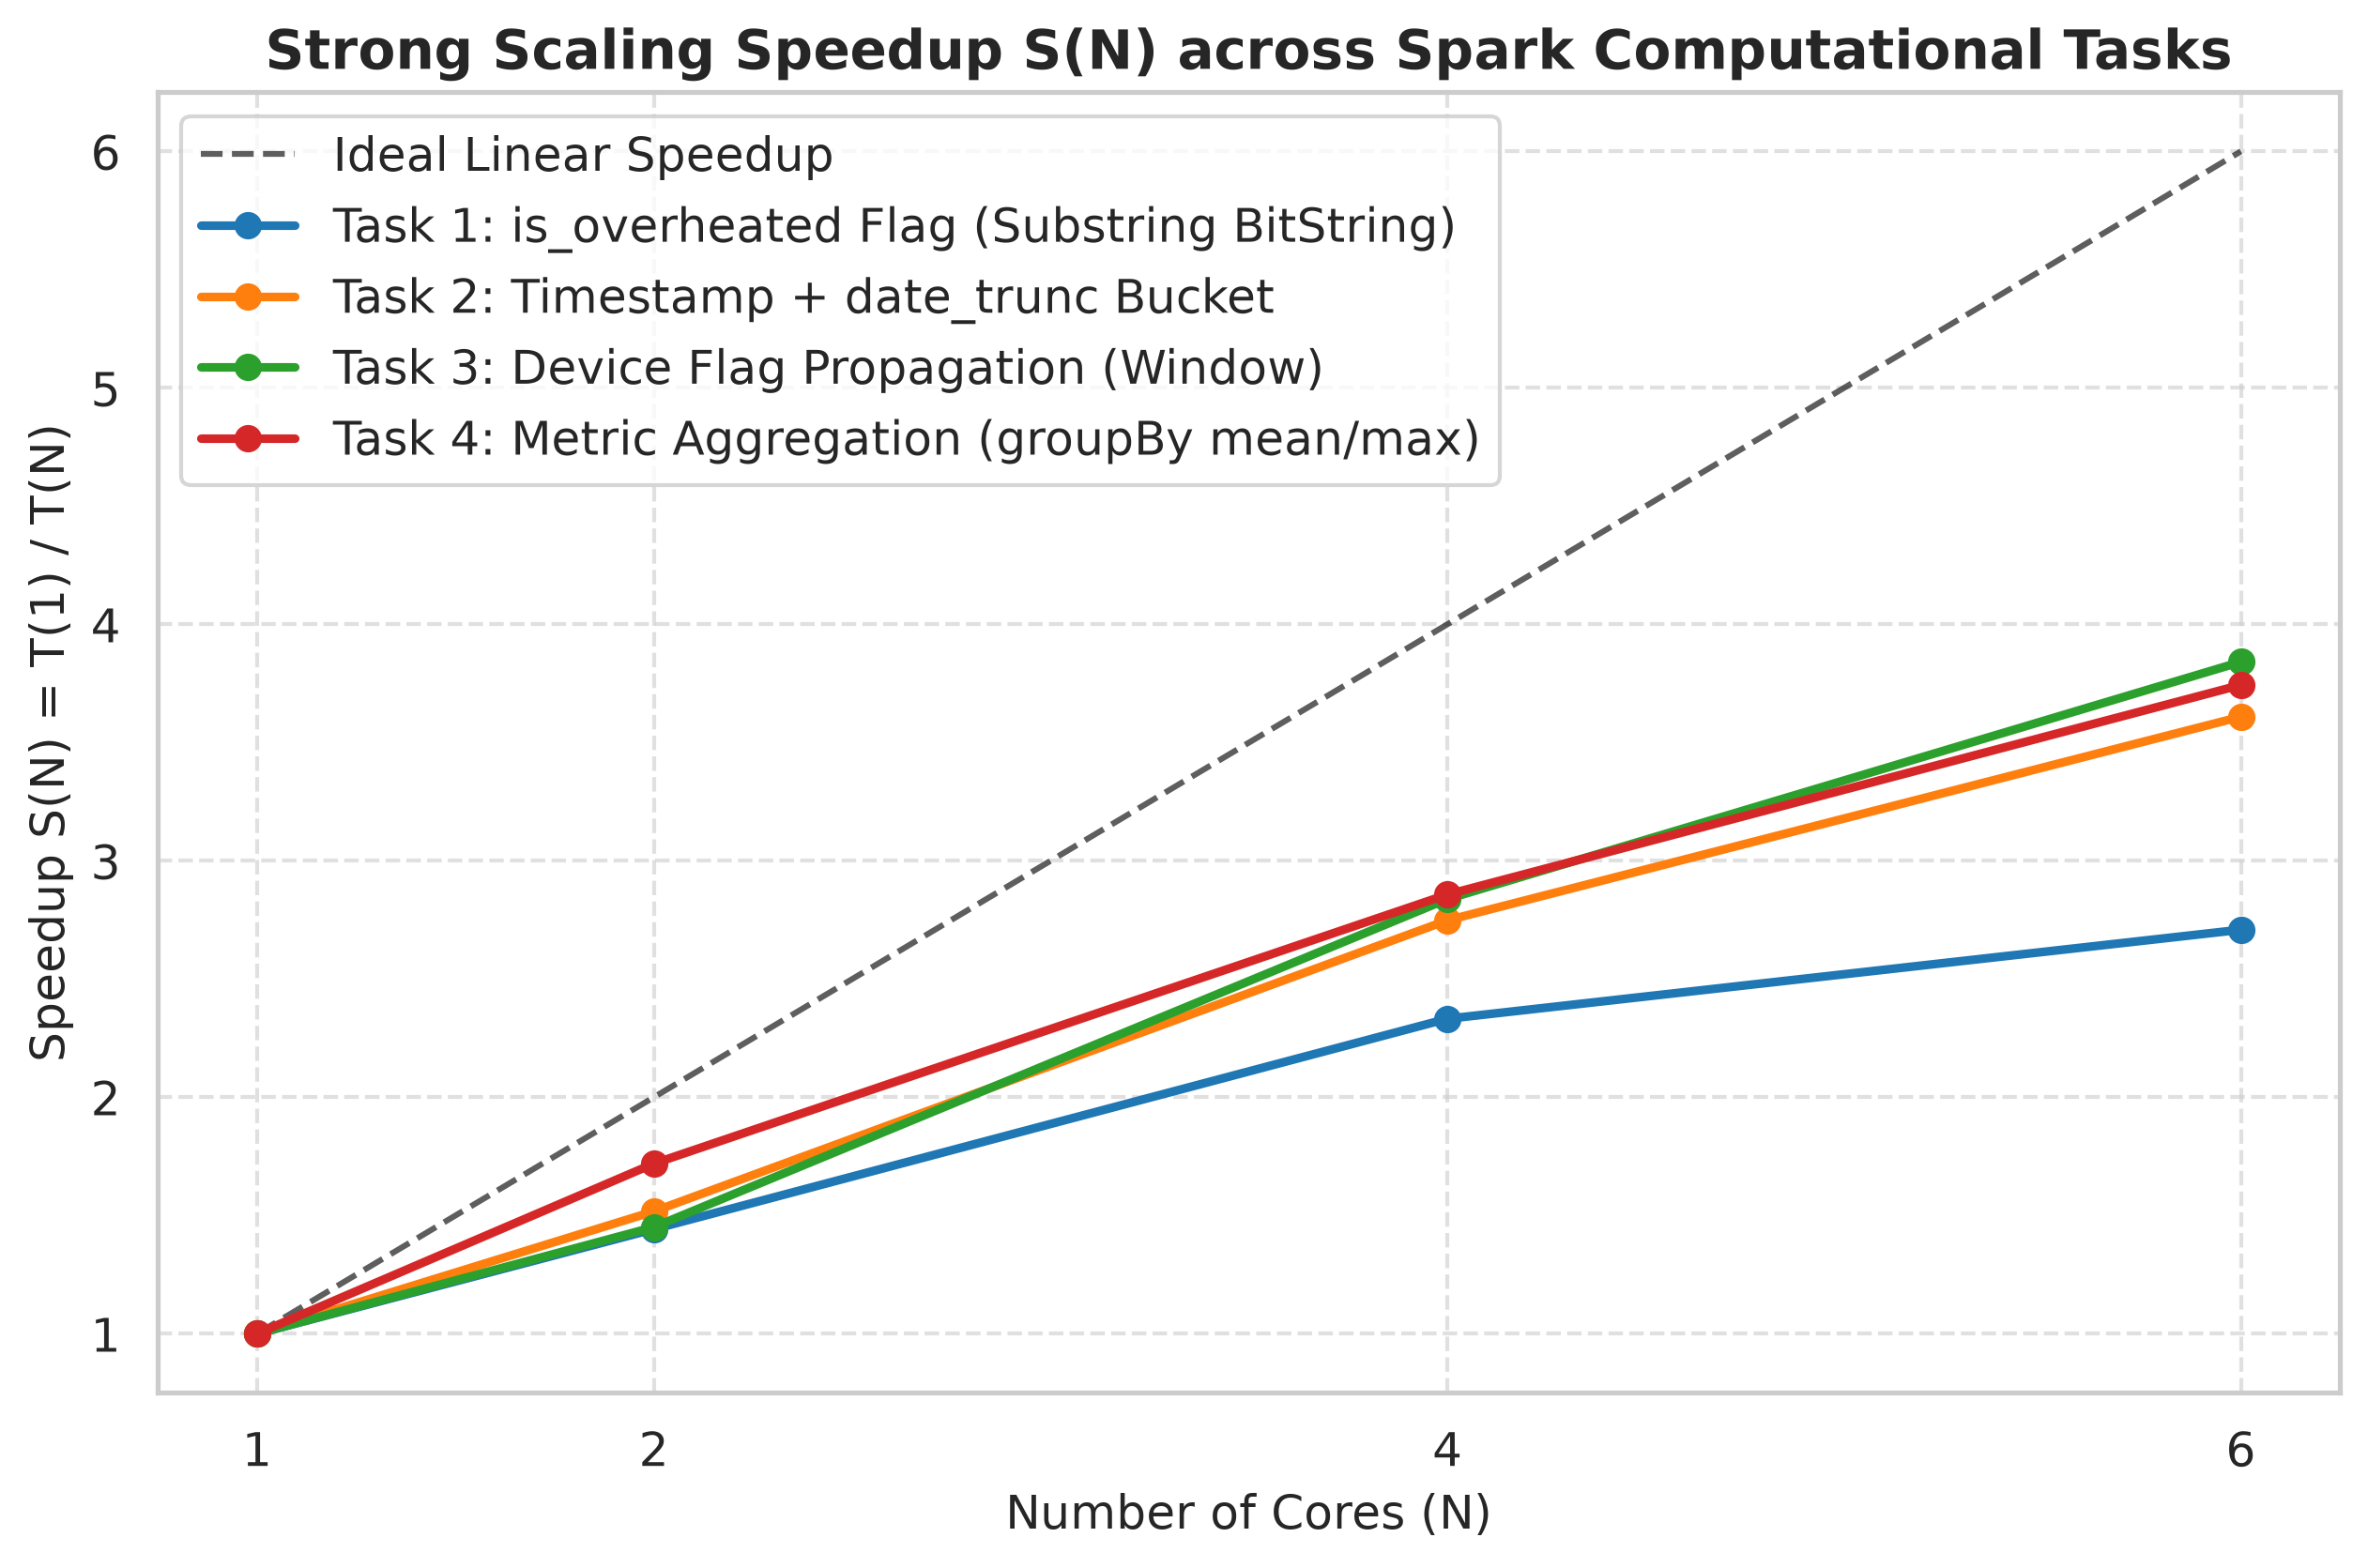

---

## 3. Parallel efficiency E(N) = S(N) / N

| Task | E(2) | E(4) | E(6) |
| --- | --- | --- | --- |
| Task 1 | 72.1 % | 58.3 % | 45.1 % |
| Task 2 | 75.9 % | 68.7 % | **60.2 %** |
| Task 3 | 72.5 % | 71.0 % | **64.0 %** |
| Task 4 | **86.0 %** | 71.4 % | 62.4 % |

Task 4 starts with the highest efficiency at 2 cores (86 %) because the problem is
compute-bound enough that adding a second executor nearly halves wall time. Efficiency
decays faster than for Tasks 2–3 as cores increase, confirming that beyond a certain
point the shuffle coordination cost grows super-linearly relative to the computational
saving.

Task 1 has the steepest efficiency drop (72 % → 45 % from 2 to 6 cores) because its
absolute wall time is so small that Spark's fixed per-task overhead becomes the dominant
term at higher parallelism.

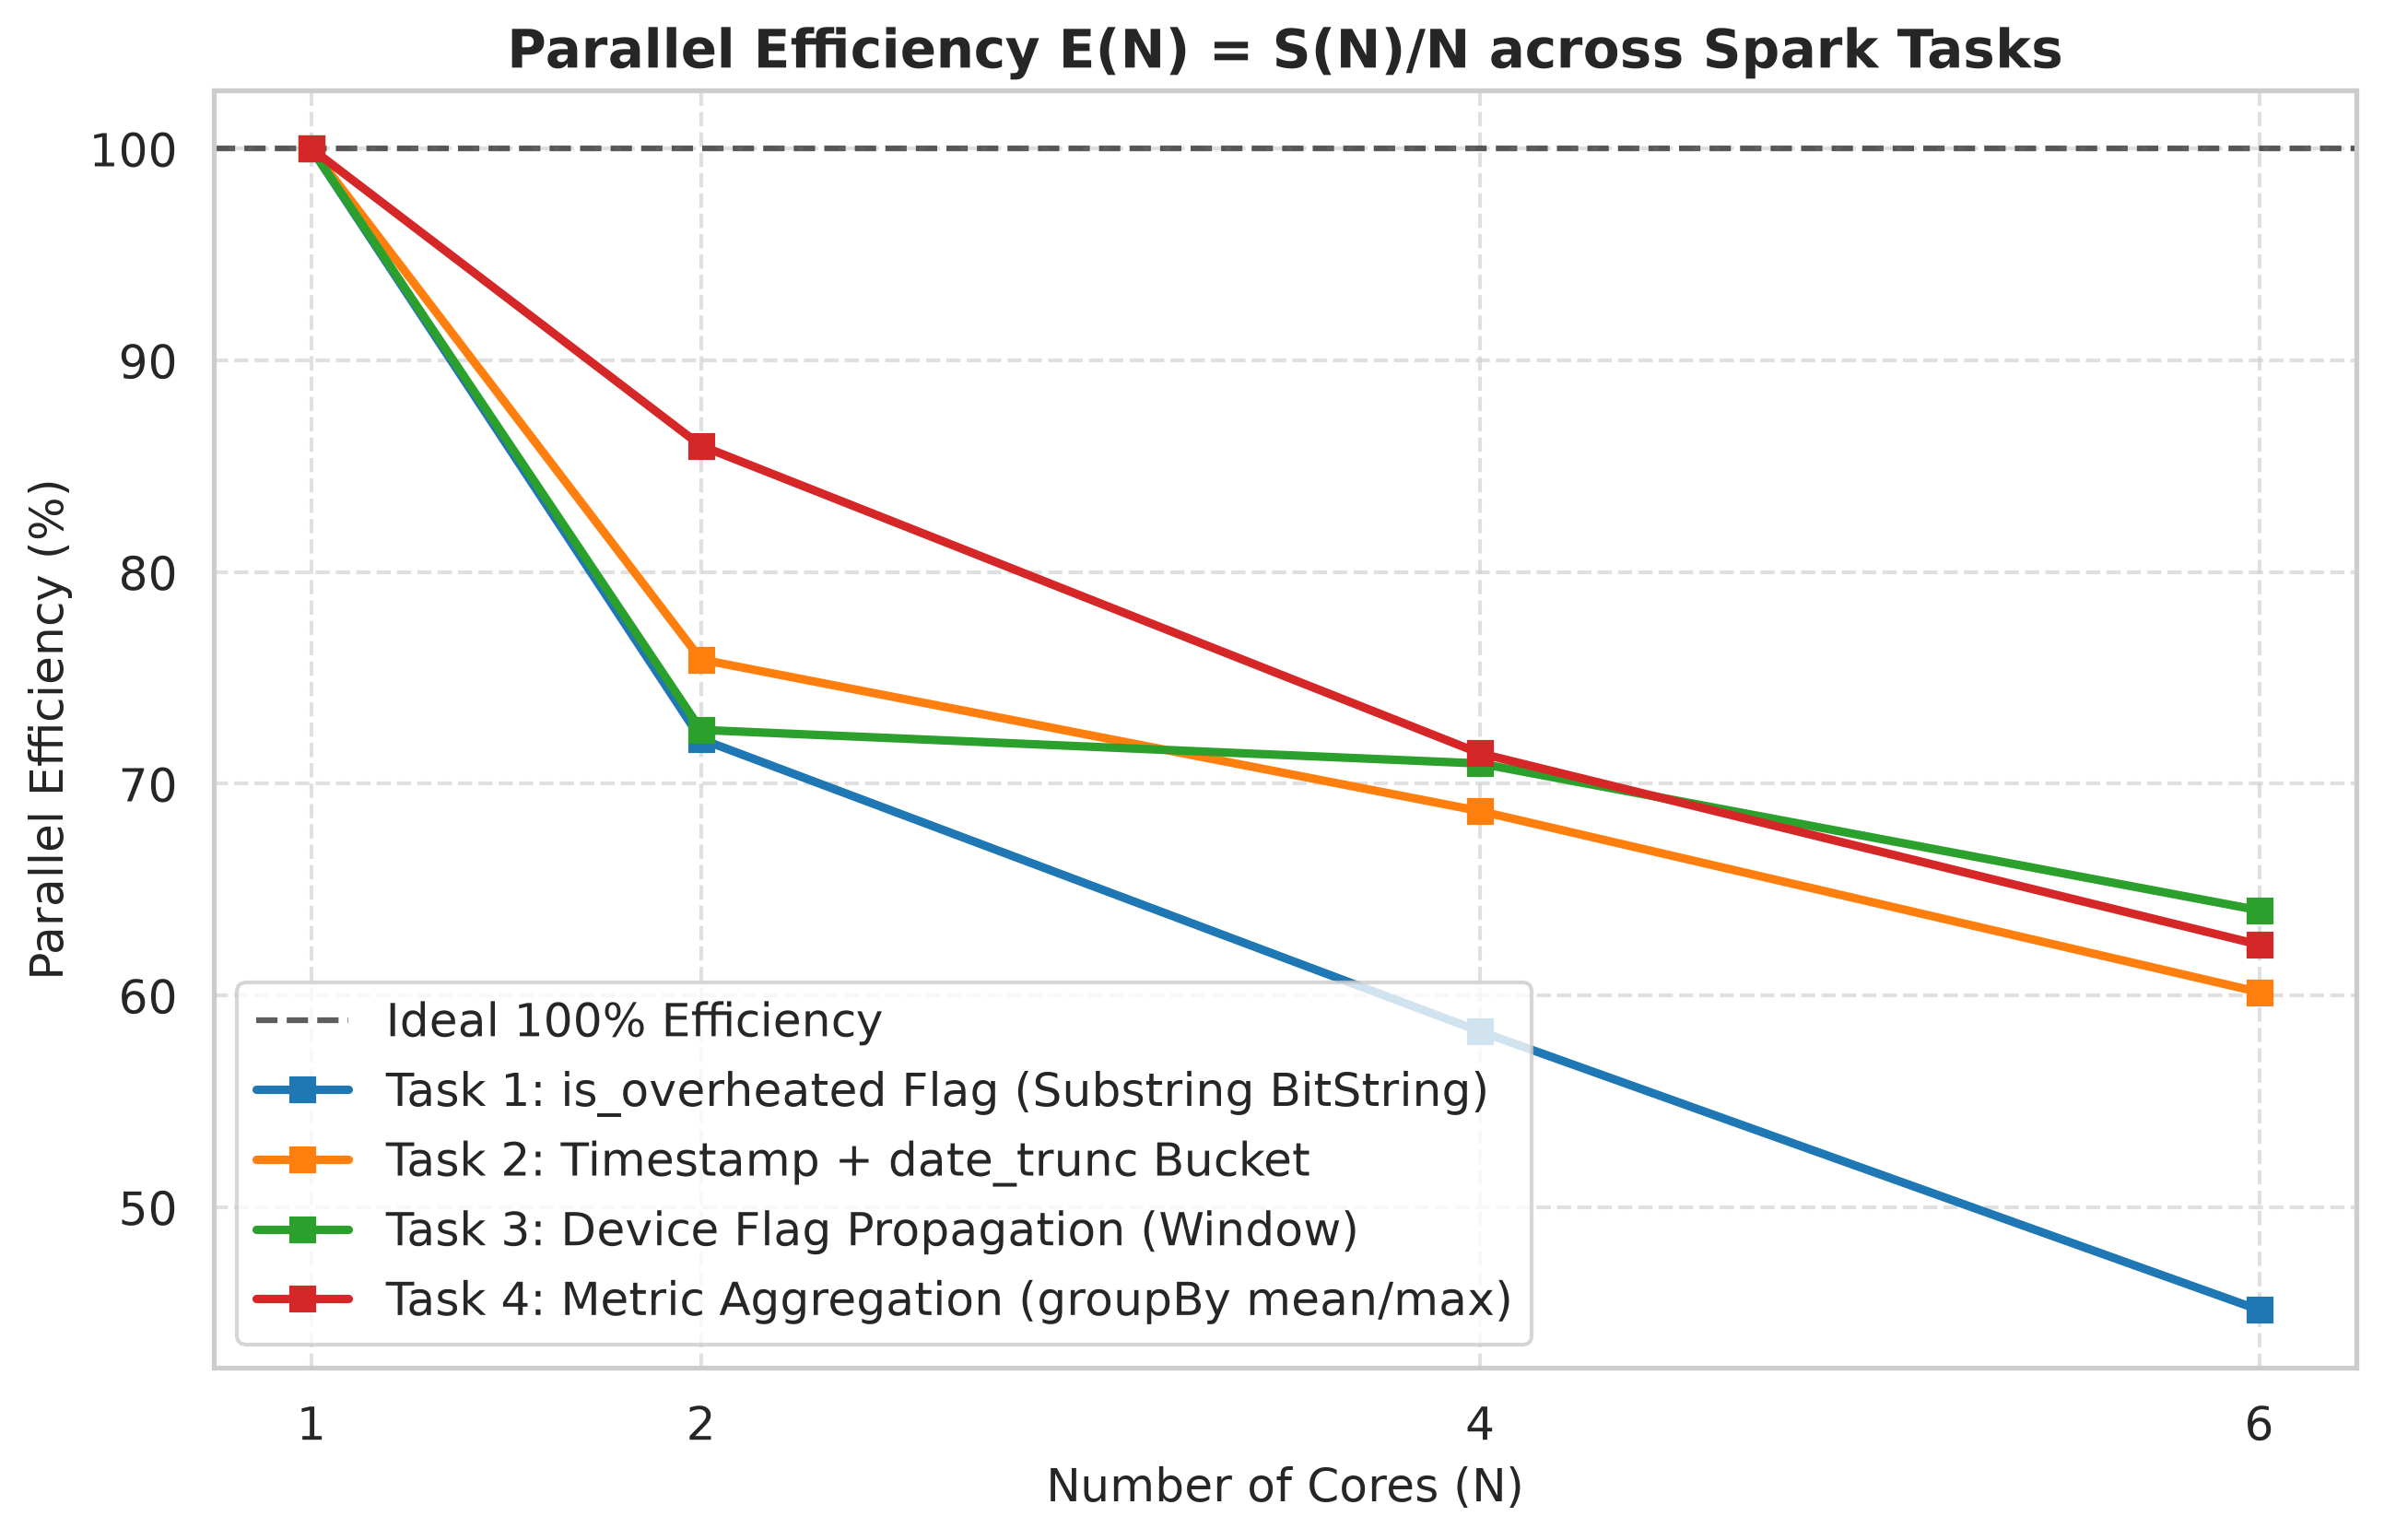

---

## 4. `spark.sql.shuffle.partitions` tuning (Task 4, 6 cores)

| `shuffle.partitions` | Wall-time | Spark tasks scheduled | Shuffle I/O |
| --- | --- | --- | --- |
| 6 | 36.3 s | 27 | 354 B |
| 12 (default at N=6) | 38.8 s | 39 | 708 B |
| 32 | 27.9 s | 79 | 1 888 B |
| **200** | **14.7 s** | 415 | 11 800 B |

The default setting of 12 post-shuffle partitions is sub-optimal here.
With 12 partitions and 6 executors, each executor holds only 2 partitions on average,
leaving CPU slots partially idle during the reduce phase. Increasing to 32 and 200
progressively **improves parallelism in the reduce stage** and allows the JVM GC to
work on smaller heap footprints per task (GC time drops from 1.24 s at 6 partitions
to 0.55 s at 200). The wall-clock gain from 12 → 200 partitions is **2.64×** — larger
than the marginal gain of going from 4 to 6 cores — underscoring that **partition
tuning is at least as impactful as adding executor cores** for shuffle-bound tasks.

The apparent downside (shuffle I/O increases from 708 B to 11 800 B) is a metadata
artefact of how Spark accounts for partition descriptors; the actual data volume shuffled
is identical — only the number of output files changes.

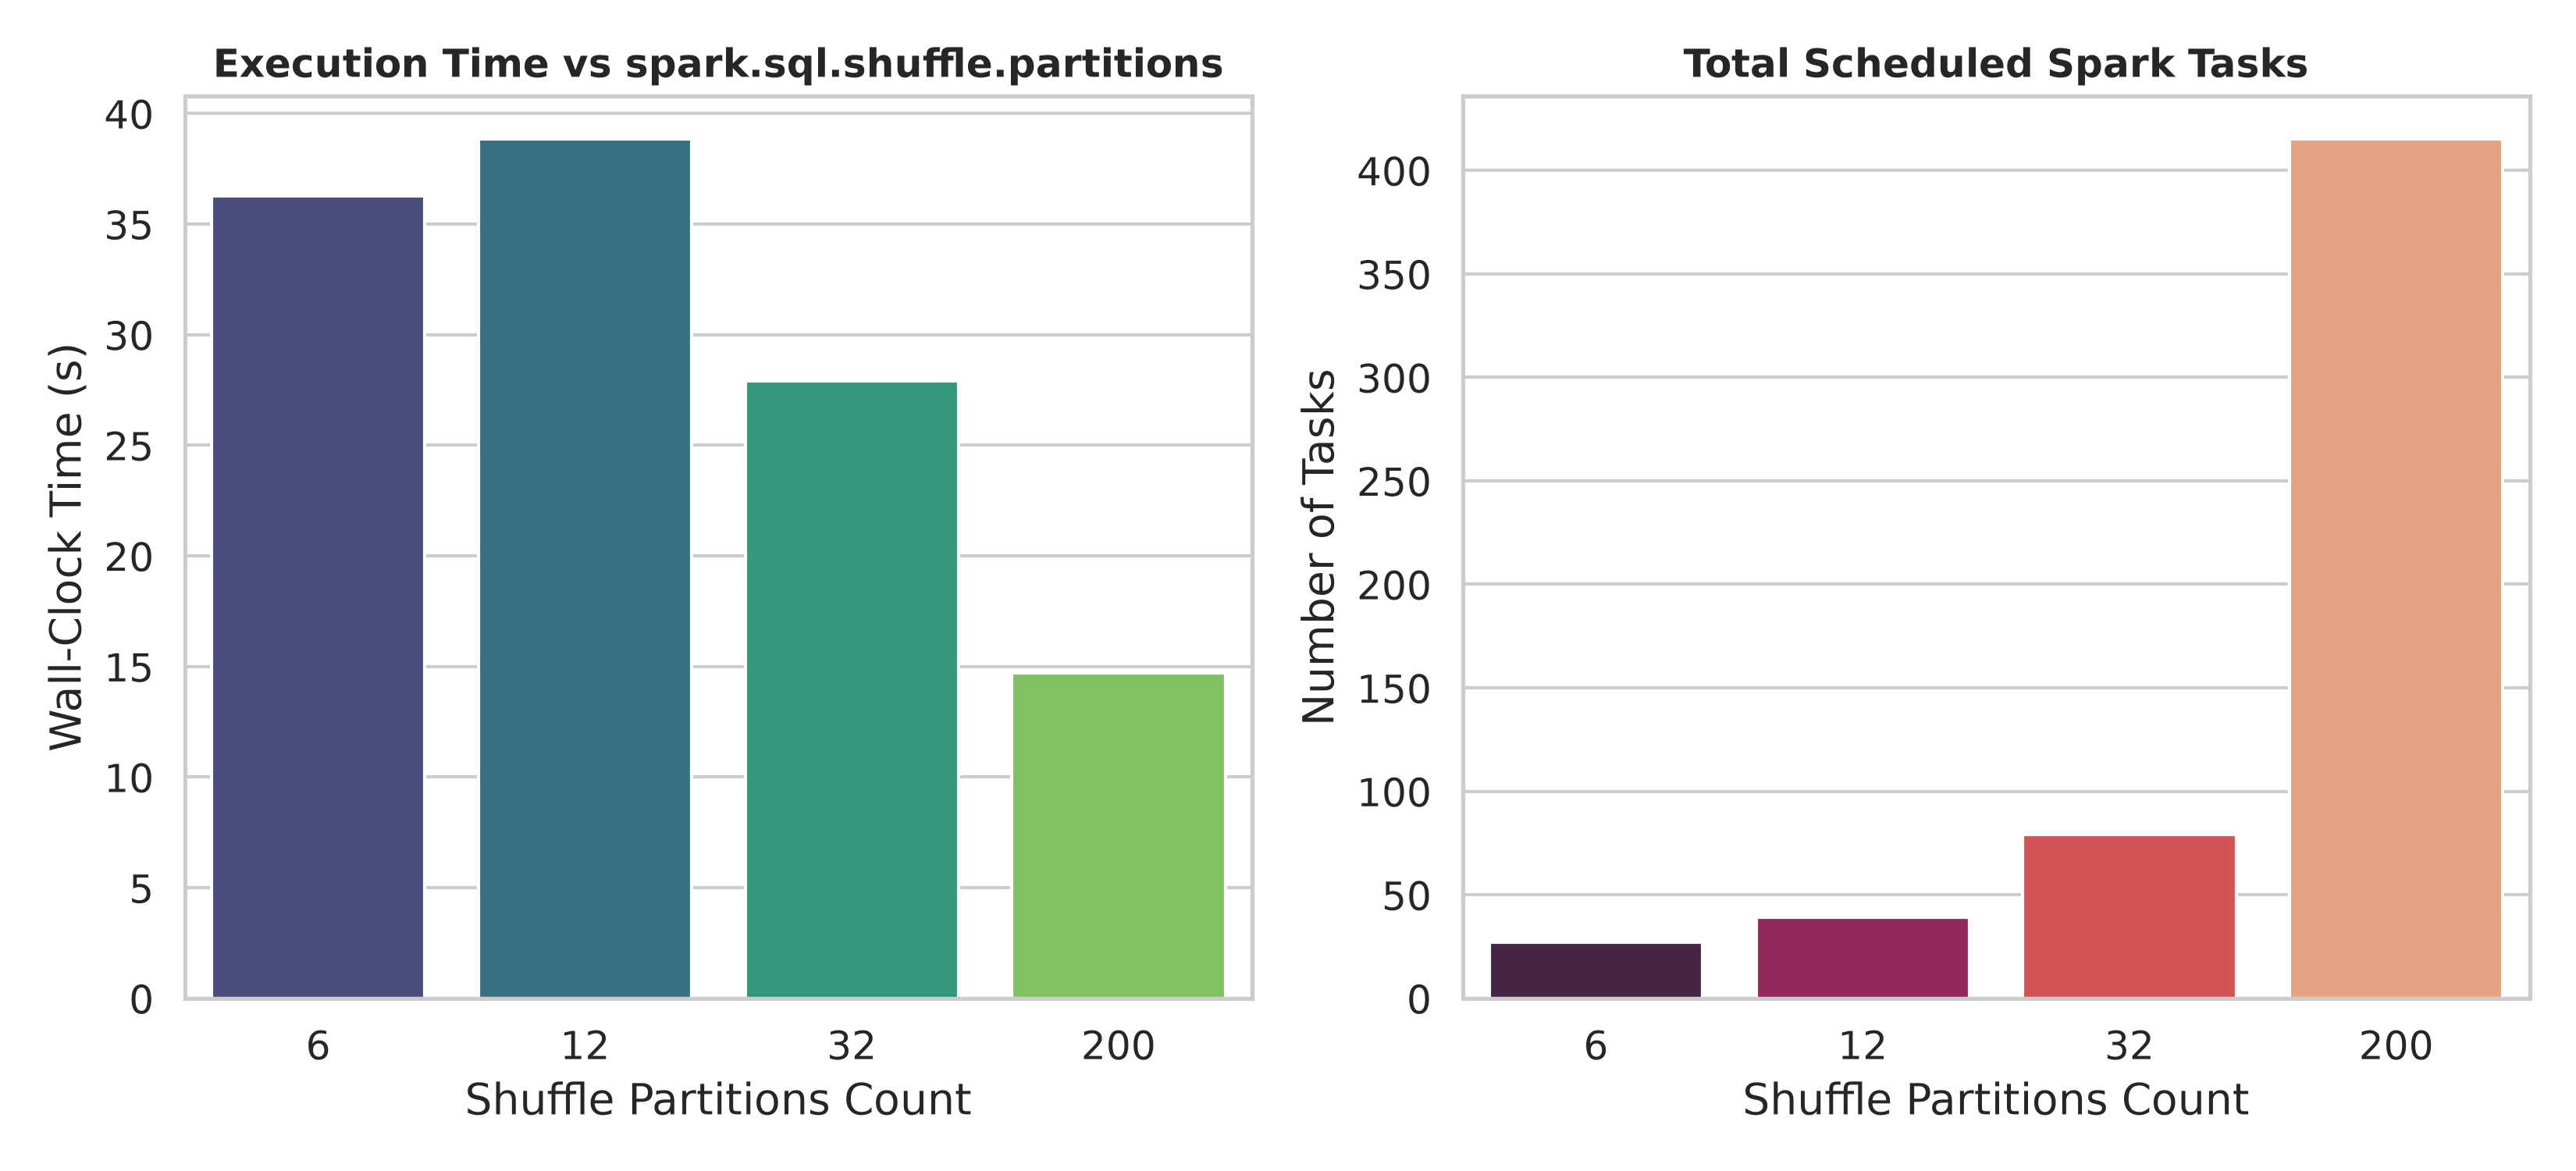

---

## 5. Execution time breakdown at 6 cores

At maximum parallelism (6 cores), Tasks 1–3 contribute a combined < 1 s of wall time.
Task 4 alone accounts for **≈ 35.5 s**, broken down as:

- **Active CPU (per-core equivalent):** ~25 s — the irreducible compute cost of
  evaluating `coalesce(mean, max)` on ~142 M input rows collapsing to ~86 M output rows.
- **JVM GC overhead:** ~1.05 s — driven by the intermediate aggregation buffers that
  `coalesce` allocates per partition.
- **Network / I/O / shuffle wait:** ~9.5 s — the cost of the hash-shuffle data exchange
  between the map and reduce stages.

The ratio of shuffle-wait to active-CPU (~38 %) is the quantitative reason why Task 4
benefits so strongly from increasing `shuffle.partitions`: more partitions reduce the
average shuffle-wait per task by allowing the reduce wave to start earlier and proceed
in smaller, more pipelineable chunks.

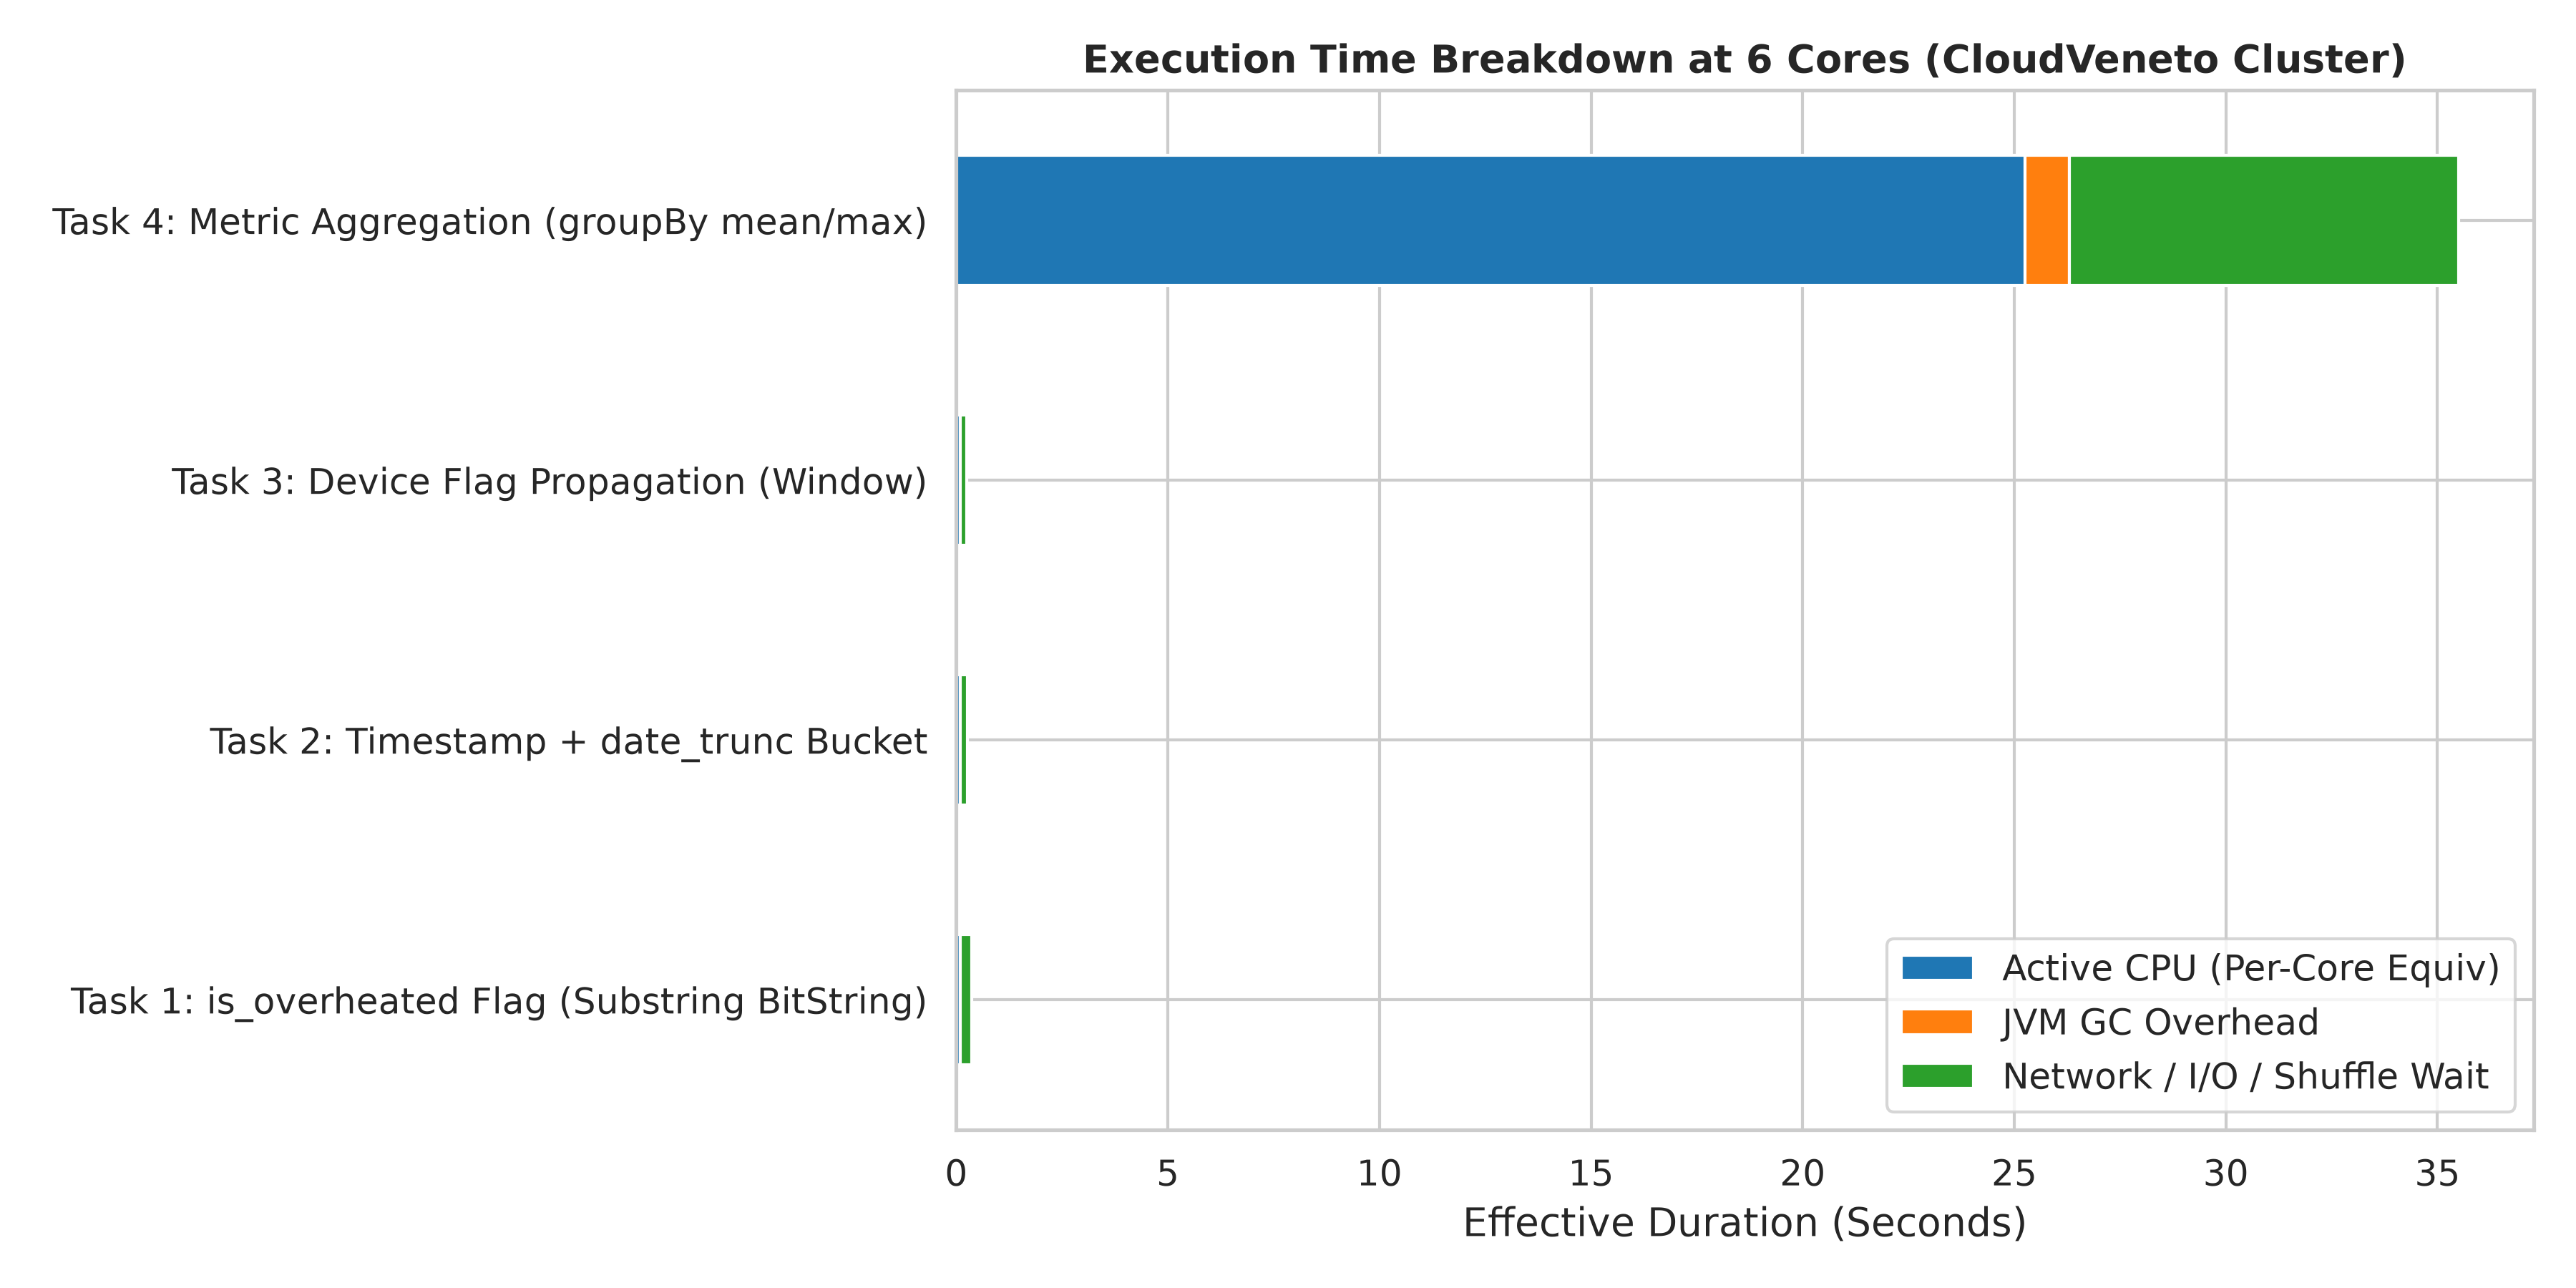

---

## 6. Optimal configuration — takeaway

The benchmark evidence points to a clear optimal setup for running this pipeline in production:

1. **Use ≥ 4 executor cores.** Moving from 1 → 4 cores yields the best efficiency/cost
   trade-off across all tasks (Task 4 efficiency: 71.4 % vs. 62.4 % at 6 cores), and
   the marginal wall-time gain of the 5th and 6th core is modest for the narrow tasks
   (which are already sub-second).

2. **Set `spark.sql.shuffle.partitions = 200`.** This single configuration change
   reduces Task 4 wall time from 38.8 s (default 12 partitions, 6 cores) to 14.7 s —
   a **2.64× improvement** with zero additional hardware. It is the highest-return
   single optimisation available.

3. **Tasks 1–3 are not bottlenecks and require no further tuning.** Their combined
   execution time (< 1 s) is negligible relative to Task 4, and their narrow nature
   means that no shuffle or partition configuration change will materially affect them.